<a href="https://colab.research.google.com/github/gagangowda31ku-png/Apple-and-Orange-Yield-prediction/blob/main/cifar10_image_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-------------$$$$$$$$ CIFAR-10 IMAGE CLASSIFACTION $$$$$$$$$---------------------

In [1]:
import os
import torch
import tarfile
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torchvision.datasets.utils import download_url
from torch.utils.data import DataLoader , random_split
import torchvision
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data_url = "https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz"
download_url(data_url , '.')

In [3]:
with tarfile.open("./cifar10.tgz",'r:gz') as tar:
  tar.extractall(path='./data')


/tmp/ipykernel_48195/1341103143.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='./data')


In [4]:
data_dir ='./data/cifar10'

In [5]:
print(os.listdir(data_dir))
classes = os.listdir(data_dir+"/train")
print(classes)

['train', 'test']
['deer', 'bird', 'airplane', 'horse', 'truck', 'cat', 'dog', 'automobile', 'frog', 'ship']


In [6]:
airoplane_file = os.listdir(data_dir+"/train/airplane")
print("number of training examples for airplane: ",len(airoplane_file))
print(airoplane_file[:2])

number of training examples for airplane:  5000
['0930.png', '2973.png']


In [7]:
truck_test_file = os.listdir(data_dir+"/test/truck")
print("Number of test examples for truck: ",len(truck_test_file))
print(truck_test_file[:2])


Number of test examples for truck:  1000
['0930.png', '0439.png']


In [8]:
dataset = ImageFolder(data_dir+"/train", transform = ToTensor())

In [9]:
dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [10]:
def show_example(img,label):
  print("Label: ",dataset.classes[label],'(',str(label),')')
  plt.imshow(img.permute(1,2,0))


Label:  airplane ( 0 )


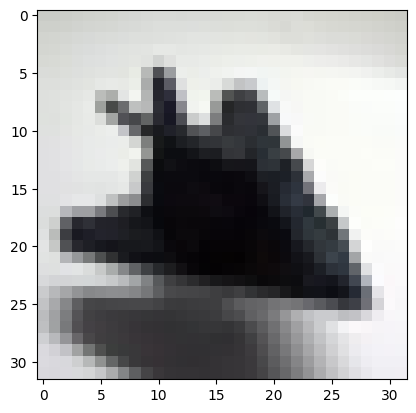

In [11]:
show_example(*dataset[0])

Label:  airplane ( 0 )


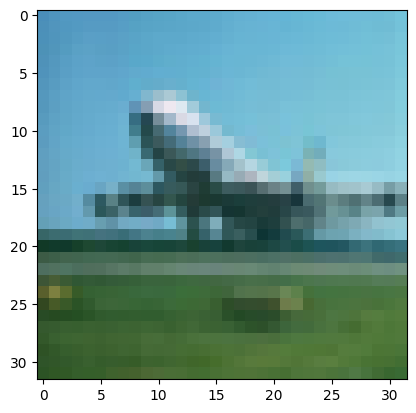

In [12]:
show_example(*dataset[100])

Label:  automobile ( 1 )


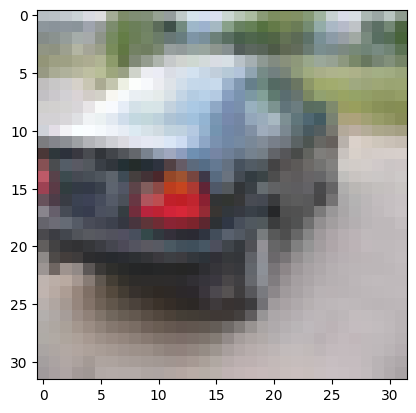

In [13]:
show_example(*dataset[6000])

In [14]:
train_ds ,val_ds = random_split(dataset , [45000,5000])
len(train_ds), len(val_ds)

(45000, 5000)

In [15]:
train_loader = DataLoader(train_ds , batch_size = 128 , shuffle = True , pin_memory = True , num_workers = 4)
val_loader = DataLoader(val_ds , batch_size = 128*2 , shuffle = True , pin_memory = True , num_workers = 4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [16]:
for image , label in train_loader:
  print(image.shape)
  print(label)
  break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([128, 3, 32, 32])
tensor([4, 7, 7, 6, 3, 1, 1, 4, 1, 8, 8, 4, 9, 4, 2, 8, 4, 3, 3, 5, 1, 5, 1, 8,
        4, 2, 1, 5, 4, 1, 6, 8, 8, 8, 9, 8, 2, 9, 9, 5, 4, 1, 3, 2, 1, 2, 1, 8,
        2, 5, 9, 9, 9, 4, 4, 9, 8, 3, 0, 2, 4, 3, 8, 6, 2, 3, 6, 7, 8, 4, 4, 6,
        5, 1, 3, 9, 6, 0, 3, 3, 4, 2, 2, 4, 3, 1, 7, 0, 8, 5, 8, 4, 9, 1, 5, 1,
        6, 0, 9, 3, 5, 2, 9, 3, 7, 2, 7, 4, 5, 2, 5, 0, 3, 6, 9, 5, 3, 1, 7, 5,
        5, 6, 0, 7, 4, 0, 9, 3])


In [17]:
from torchvision.utils import make_grid

In [18]:
def show_batch(dataloader):
  for image , label in train_loader:
    plt.figure(figsize = (16,8))
    plt.axis("off")
    plt.imshow(make_grid(image , nrow =16).permute(1,2,0))
    break

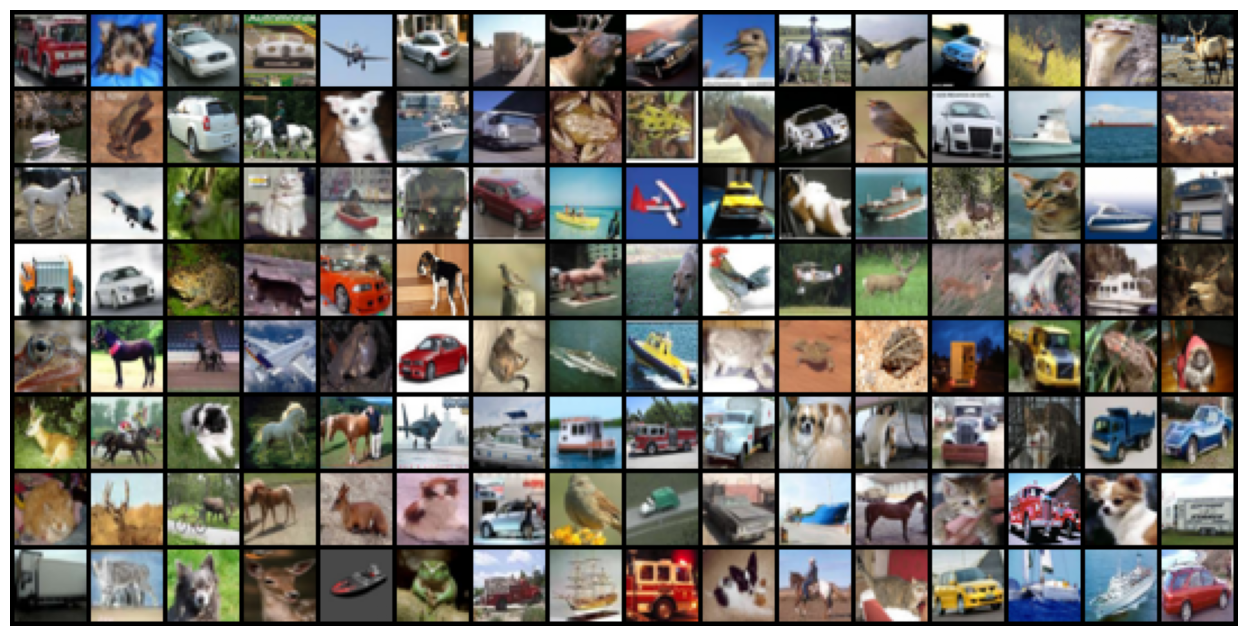

In [19]:
show_batch(train_loader)

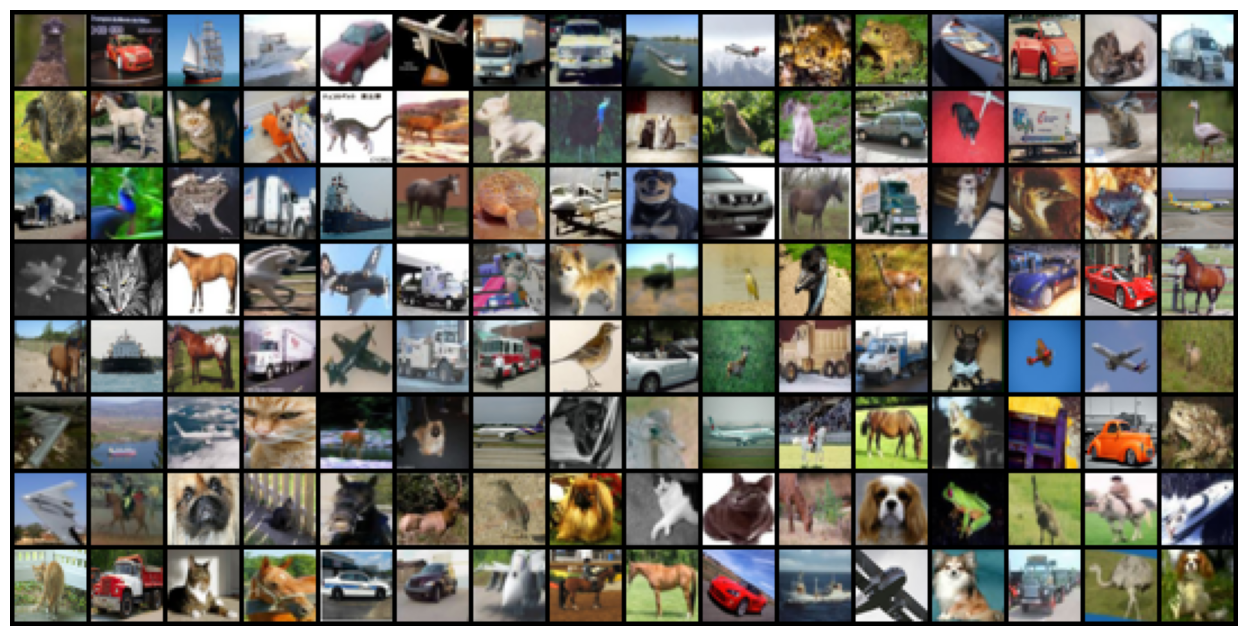

In [20]:
show_batch(val_loader)

In [21]:
def apply_kernal(image , kernal):
  ri , ci = image.shape
  rk , ck = kernal.shape
  ro , co = ri - rk + 1 , ci - ck + 1
  output = torch.zeros([ro,co])
  for i in range(ro):
    for j in range(co):
      output[i,j] = torch.sum(image[i:i+rk , j: j + ck]* kernal)
  return output

In [22]:
import numpy as np
sample_input = np.random.randint(0,4 , [5,5])
sample_kernal = np.random.randint(1,3,[3,3])

In [23]:
print(sample_input)

[[0 3 0 2 3]
 [3 2 1 0 2]
 [2 3 2 1 2]
 [0 1 0 1 0]
 [3 3 2 1 0]]


In [24]:
print(sample_kernal)

[[2 2 2]
 [1 2 1]
 [2 2 1]]


In [25]:
sample_input = torch.from_numpy(sample_input)
sample_kernal = torch.from_numpy(sample_kernal)

In [26]:
apply_kernal(sample_input , sample_kernal)

tensor([[26., 25., 21.],
        [24., 17., 14.],
        [30., 25., 18.]])

In [27]:
conv = nn.Conv2d(3,8,kernel_size=3,stride=1,padding=1)

In [28]:
for image ,label in train_loader:
  print(image.shape)
  out = conv(image)
  print(out.shape)
  break

torch.Size([128, 3, 32, 32])
torch.Size([128, 8, 32, 32])


In [29]:
conv = nn.Conv2d(3,8, kernel_size = 3 , stride = 1 ,padding =1)
pool = nn.MaxPool2d(2,2)

In [30]:
for image , label in train_loader:
  print(image.shape)
  out = conv(image)
  print(out.shape)
  pool_out = pool(out)
  print(pool_out.shape)
  break

torch.Size([128, 3, 32, 32])
torch.Size([128, 8, 32, 32])
torch.Size([128, 8, 16, 16])


In [31]:
sample_model = nn.Sequential(
    nn.Conv2d(3,8 ,kernel_size = 3,stride=1,padding=1),
    nn.MaxPool2d(2,2)
)

In [32]:



for image , label in train_loader:
  print(image.shape)
  out = sample_model(image)
  print(out.shape)
  break

torch.Size([128, 3, 32, 32])
torch.Size([128, 8, 16, 16])


In [33]:

class ImageClassificationBase(nn.Module):
  def train_step(self,batch):
    image, label = batch
    out = self(image)
    loss = F.cross_entropy(out,label)
    return loss

  def validation_step(self,batch):
    image , label = batch
    out = self(image)
    loss= F.cross_entropy(out,label)
    acc = accuracy(out,label)
    return {'val_loss':loss.detach(),'val_acc':acc}

  def validation_epoch_end(self,output):
    batch_loss = [x['val_loss'] for x in output]
    epoch_loss = torch.stack(batch_loss).mean()
    batch_acc = [x['val_acc'] for x in output]
    epoch_acc = torch.stack(batch_acc).mean()
    return {'val_loss':epoch_loss.item(),'val_acc':epoch_acc.item()}


  def epoch_end(self,epoch,result):
    print(f"Epoch[{epoch}] , train_loss:{result['train_loss']:.4f}, val_loss:{result['val_loss']:.4f}, val_acc:{result['val_acc']:.4f}")

def accuracy(output ,label):
  _ , preds = torch.max(output , dim = 1)
  return torch.tensor(torch.sum(preds == label).item()/len(preds))



In [34]:
class Cifar10cnnModel(ImageClassificationBase):
  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Conv2d(3,32, kernel_size = 3 , stride =1, padding = 1),
        nn.ReLU(),
        nn.Conv2d(32,64 , kernel_size = 3, stride=1,padding =1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(64,128 , kernel_size =3 , stride = 1 , padding= 1),
        nn.ReLU(),
        nn.Conv2d(128,128 , kernel_size = 3 , stride=1, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(128 , 256,kernel_size =3 , stride = 1 , padding = 1),
        nn.ReLU(),
        nn.Conv2d(256 , 256 , kernel_size = 3 , stride = 1 , padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),


        nn.Flatten(),
        nn.Linear(256*4*4 , 1024),
        nn.ReLU(0),
        nn.Linear(1024 , 512),
        nn.ReLU(),
        nn.Linear(512 , 10)

    )


  def forward(self,xb):
    return self.network(xb)




In [35]:
model = Cifar10cnnModel()


In [36]:

for image , label in train_loader:
  print(image.shape)
  out = model(image)
  print(out.shape)
  break

torch.Size([128, 3, 32, 32])
torch.Size([128, 10])


In [37]:
torch.cuda.is_available()

True

In [38]:
def get_defualt_device():
  if torch.cuda.is_available():
    return torch.device('cuda')
  else:
    return torch.device('cpu')

def to_device(data , device):
  if isinstance(data ,(list , tuple)):
    return [to_device(x , device)for x in data]

  return data.to(device , non_blocking = True)

device = get_defualt_device()


class DeviceDataLoader:
  def __init__(self,dl,device):
    self.dl = dl
    self.device = device

  def __iter__(self):
    for batch in self.dl:
      yield to_device(batch , device)

    def __len__(self):
      return len(self.dl)

In [39]:
train_loader = DeviceDataLoader(train_loader , device)
val_loader = DeviceDataLoader(val_loader , device)
to_device(model ,device)

Cifar10cnnModel(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Flatten(start_dim=1, end_dim=-1)
    (16): Linear(in_features=4096, out_features=1024, bias=True)
    (17): ReLU()
    (18): Linear(in_feat

In [40]:
@torch.no_grad()
def evaluate(model , val_loader):
  model.eval()
  output = [model.validation_step(batch) for batch in val_loader]
  return model.validation_epoch_end(output)

In [41]:
def fit(epochs , lr, model , train_loader , val_loader):
  opt_fn = torch.optim.Adam
  optimizer = opt_fn(model.parameters() , lr = lr)
  history = []
  for epoch in range(epochs):
    model.train()
    train_losses = []
    for batch in train_loader:
      loss = model.train_step(batch)
      train_losses.append(loss)
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    result = evaluate(model,val_loader)
    result['train_loss'] = torch.stack(train_losses).mean().item()
    model.epoch_end(epochs , result)
    history.append(result)
  return history




In [42]:
model = Cifar10cnnModel()
to_device(model , device)

Cifar10cnnModel(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Flatten(start_dim=1, end_dim=-1)
    (16): Linear(in_features=4096, out_features=1024, bias=True)
    (17): ReLU()
    (18): Linear(in_feat

In [43]:
history1 = fit(10 , 0.001 , model, train_loader , val_loader)

Epoch[10] , train_loss:1.7349, val_loss:1.3297, val_acc:0.5061
Epoch[10] , train_loss:1.1756, val_loss:1.0642, val_acc:0.6239
Epoch[10] , train_loss:0.9186, val_loss:0.8299, val_acc:0.7162
Epoch[10] , train_loss:0.7431, val_loss:0.7705, val_acc:0.7276
Epoch[10] , train_loss:0.6167, val_loss:0.6735, val_acc:0.7683
Epoch[10] , train_loss:0.5117, val_loss:0.6750, val_acc:0.7737
Epoch[10] , train_loss:0.4101, val_loss:0.6842, val_acc:0.7788
Epoch[10] , train_loss:0.3247, val_loss:0.7509, val_acc:0.7651
Epoch[10] , train_loss:0.2502, val_loss:0.7644, val_acc:0.7774
Epoch[10] , train_loss:0.1947, val_loss:0.8862, val_acc:0.7715


In [44]:
history2 = fit(10 , 0.001 , model, train_loader , val_loader)

Epoch[10] , train_loss:0.1510, val_loss:0.9348, val_acc:0.7916
Epoch[10] , train_loss:0.1193, val_loss:1.0069, val_acc:0.7820
Epoch[10] , train_loss:0.1023, val_loss:1.0267, val_acc:0.7781
Epoch[10] , train_loss:0.0988, val_loss:1.0855, val_acc:0.7796
Epoch[10] , train_loss:0.0924, val_loss:1.1312, val_acc:0.7745
Epoch[10] , train_loss:0.0848, val_loss:1.2415, val_acc:0.7894
Epoch[10] , train_loss:0.0691, val_loss:1.2336, val_acc:0.7731
Epoch[10] , train_loss:0.0746, val_loss:1.3043, val_acc:0.7700
Epoch[10] , train_loss:0.0744, val_loss:1.2545, val_acc:0.7839
Epoch[10] , train_loss:0.0631, val_loss:1.3366, val_acc:0.7785


In [45]:
history = history1 + history2

In [61]:
def plot_accuracies(history):
  accuracies = [result['val_acc'] for result in history]
  plt.plot(accuracies , '-xb')
  plt.title("Accuracy VS no. of epoch")
  plt.xlabel("epoch")
  plt.ylabel("accuracy")
  plt.show()

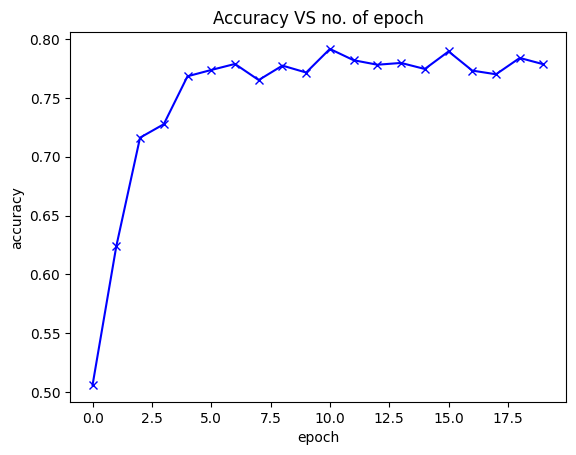

In [62]:
plot_accuracies(history)

In [63]:
def plot_losses(history):
  train_loss = [result['train_loss'] for result in history]
  val_loss = [result['val_loss'] for result in history]
  plt.plot(train_loss,'-xb')
  plt.plot(val_loss,'-xr')
  plt.title("Losses VS no. of epoch")
  plt.xlabel("epoch")
  plt.ylabel("loss")
  plt.legend(['train','val'])
  plt.show()

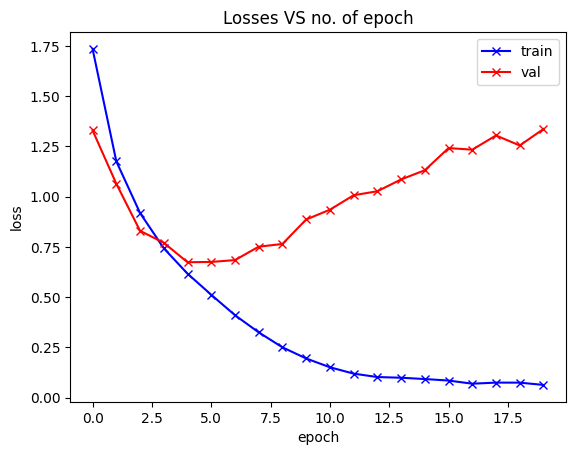

In [64]:
plot_losses(history)

In [48]:
test_dataset = ImageFolder(data_dir + "/test",  transform = ToTensor())

In [49]:
test_loader = DataLoader(test_dataset , batch_size = 128*2, pin_memory = True , num_workers = 4)


In [50]:
def predict_image(img ,model):
  xb = to_device(img.unsqueeze(0), device)
  yb = model(xb)
  _,preds = torch.max(yb,dim=1)
  return test_dataset.classes[preds[0]]

torch.Size([128, 3, 32, 32])
Lable:  airplane
Predicted label:  airplane


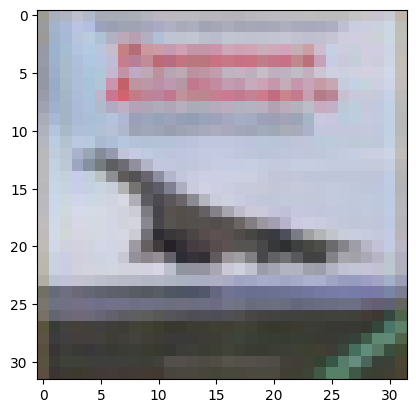

In [51]:
img , label = test_dataset[0]
print(image.shape)
print("Lable: ",test_dataset.classes[label])
plt.imshow(img.permute(1,2,0))
print("Predicted label: ",predict_image(img,model))

torch.Size([128, 3, 32, 32])
Lable:  bird
Predicted label:  bird


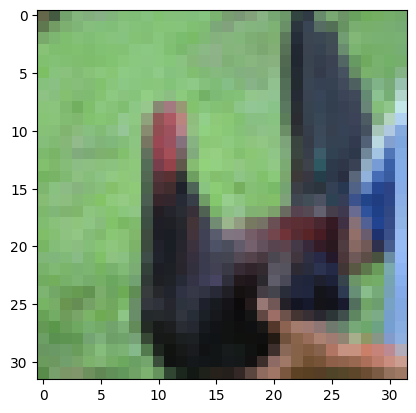

In [52]:
img , label = test_dataset[2000]
print(image.shape)
print("Lable: ",test_dataset.classes[label])
plt.imshow(img.permute(1,2,0))
print("Predicted label: ",predict_image(img,model))

In [53]:
test_loader = DeviceDataLoader(test_loader , device)

In [54]:
result = evaluate(model ,test_loader)
print(result)

{'val_loss': 1.3827086687088013, 'val_acc': 0.762011706829071}


In [55]:
torch.save(model.state_dict() , "cifar10-cnn.pth")

In [56]:
model2 = Cifar10cnnModel()

In [57]:
to_device(model2 , device)

Cifar10cnnModel(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Flatten(start_dim=1, end_dim=-1)
    (16): Linear(in_features=4096, out_features=1024, bias=True)
    (17): ReLU()
    (18): Linear(in_feat

In [58]:
model2.load_state_dict(torch.load('cifar10-cnn.pth'))

<All keys matched successfully>

In [59]:
result = evaluate(model2 , test_loader)
print(result)

{'val_loss': 1.3827086687088013, 'val_acc': 0.762011706829071}
